In [10]:
import pandas as pd;
import seaborn as sns;
import numpy as np;
import matplotlib as mt;
import matplotlib.pyplot as plt;
import re;


In [ ]:
#Rumusan masalah
#1.Apa pengaruh campaign (post-campaign, launch, pre-campaign) pada impression
#2.Apa pengaruh campaign (post-campaign, launch, pre-campaign) pada engagement-rate
#3. Hari apa dengan jumlah impression post tertinggi (5 top)

In [12]:
df = pd.read_csv("/Users/farahtrijayanti/Desktop/Data Science/Social Media Engagement Dataset.csv")
print(df.head())
print(df_new.info())

        post_id         timestamp day_of_week   platform        user_id  \
0  kcqbs6hxybia  09/12/2024 11:26      Monday  Instagram  user_52nwb0a6   
1  vkmervg4ioos  28/07/2024 19:59      Sunday    Twitter  user_ucryct98   
2  memhx4o1x6yu  23/11/2024 14:00    Saturday     Reddit  user_7rrev126   
3  bhyo6piijqt9  16/09/2024 04:35      Monday    YouTube  user_4mxuq0ax   
4  c9dkiomowakt  05/09/2024 21:03    Thursday    Twitter  user_l1vpox2k   

               location language  \
0  Melbourne, Australia       pt   
1          Tokyo, Japan       ru   
2        Beijing, China       ru   
3        Lagos, Nigeria       en   
4       Berlin, Germany       hi   

                                        text_content  \
0  Just tried the Chromebook from Google. Best pu...   
1  Just saw an ad for Microsoft Surface Laptop du...   
2  What's your opinion about Nike's Epic React?  ...   
3  Bummed out with my new Diet Pepsi from Pepsi! ...   
4  Just tried the Corolla from Toyota. Absolutely...

In [13]:
#------------------------------DATA PRE-PARATION--------------------------#

#-----IDENTIFIKASI NILAI HILANG--------#

print("Persentase nilai hilang per kolom:")
print(df.isnull().sum() /df.shape[0] * 100)
print("\n")

#------PENANGANAN--------#
df_cleaned = df.copy()
#---------PENGHAPUSAN KOLOM YANG TIDAK RELEVAN------------#
df_new = df.drop('mentions',axis=1)
print(df_new.head())

#--------MENCARI DATA DUPLIKAT-------------#

duplicate = df_new.duplicated()

#mengetahui jumlah data duplikat
print(f"\n jumlah baris duplikat: {df_new.duplicated().sum()} baris.")

#------------NORMALISASI DATA-------------------#
#mengganti tipe data object ke string

df_new['post_id'] = df_new['post_id'].astype(pd.StringDtype())
df_new['day_of_week'] = df_new['day_of_week'].astype(pd.StringDtype())
df_new['platform'] = df_new['platform'].astype(pd.StringDtype())
df_new['user_id'] = df_new['user_id'].astype(pd.StringDtype())
df_new['location'] = df_new['location'].astype(pd.StringDtype())
df_new['language'] = df_new['language'].astype(pd.StringDtype())
df_new['text_content'] = df_new['text_content'].astype(pd.StringDtype())
df_new['hashtags'] = df_new['hashtags'].astype(pd.StringDtype())
#df_new['mentions'] = df_new['mentions'].astype(pd.StringDtype())
df_new['keywords'] = df_new['keywords'].astype(pd.StringDtype())

#-----------IDENTIFYING GARBAGE VALUE---------------------#
for i in df_new.select_dtypes(include=object).columns:
    print(df_new[i].value_counts())
    print("***"*10)

#----------------------HANDLE THE MISSING VALUE---------------------#
for i in ['mentions']:
    df[i].fillna("NA", inplace=True)

Persentase nilai hilang per kolom:
post_id                     0.000000
timestamp                   0.000000
day_of_week                 0.000000
platform                    0.000000
user_id                     0.000000
location                    0.000000
language                    0.000000
text_content                0.000000
hashtags                    0.000000
mentions                   32.841667
keywords                    0.000000
topic_category              0.000000
sentiment_score             0.000000
sentiment_label             0.000000
emotion_type                0.000000
toxicity_score              0.000000
likes_count                 0.000000
shares_count                0.000000
comments_count              0.000000
impressions                 0.000000
engagement_rate             0.000000
brand_name                  0.000000
product_name                0.000000
campaign_name               0.000000
campaign_phase              0.000000
user_past_sentiment_avg     0.000000
use

/var/folders/xw/njgxzjnn7tj7ckf5mpfckf8h0000gn/T/ipykernel_1087/2509221422.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna("NA", inplace=True)


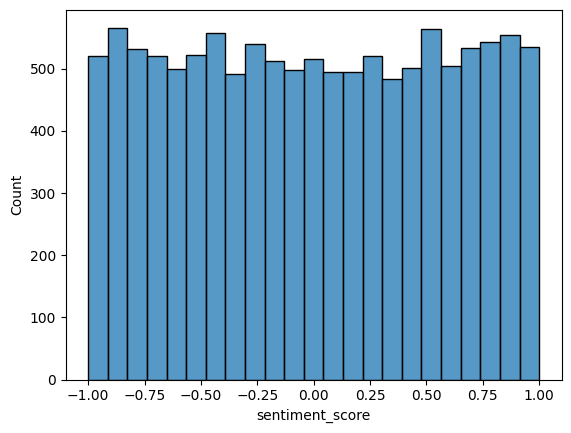

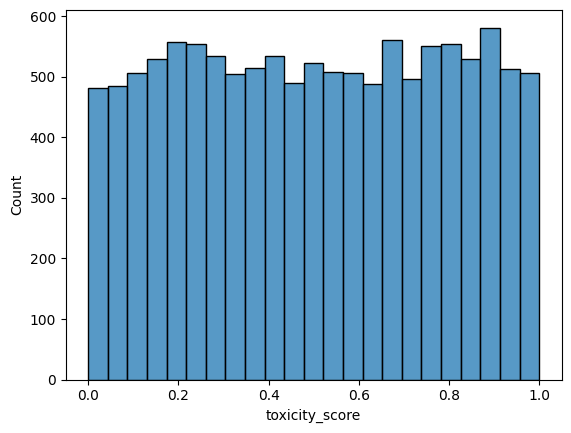

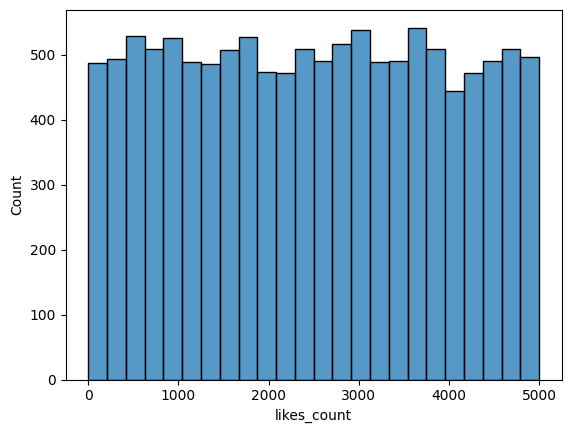

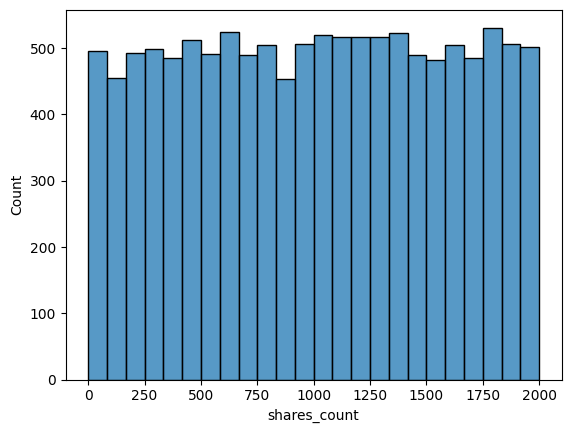

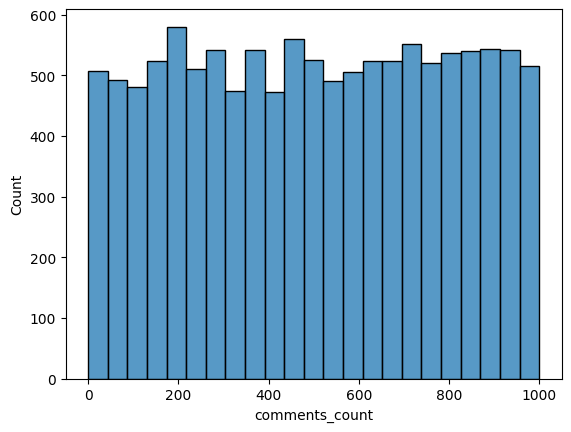

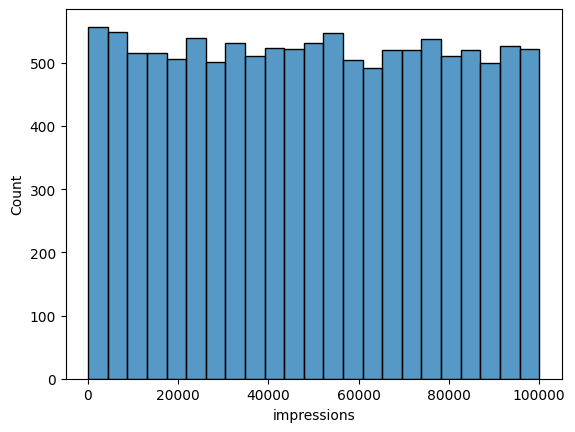

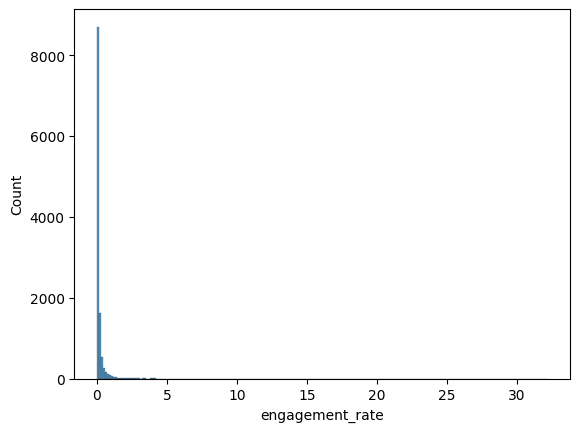

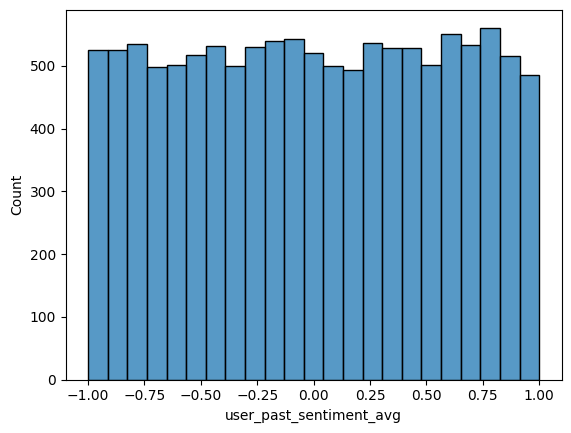

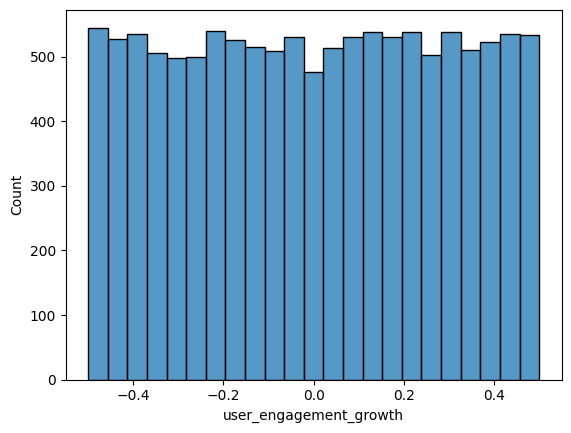

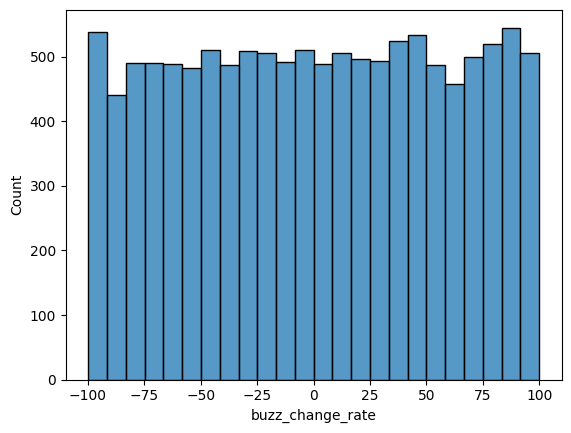

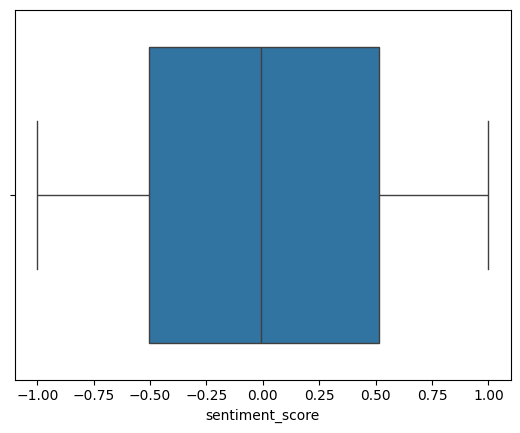

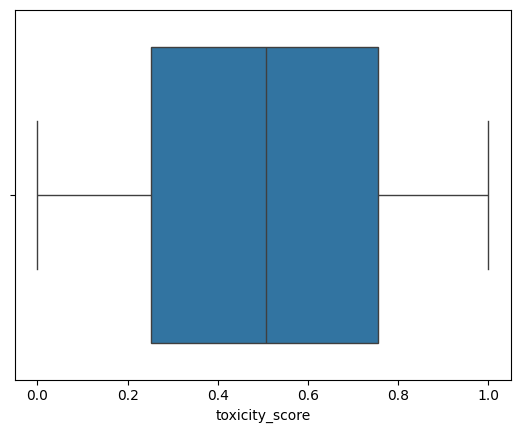

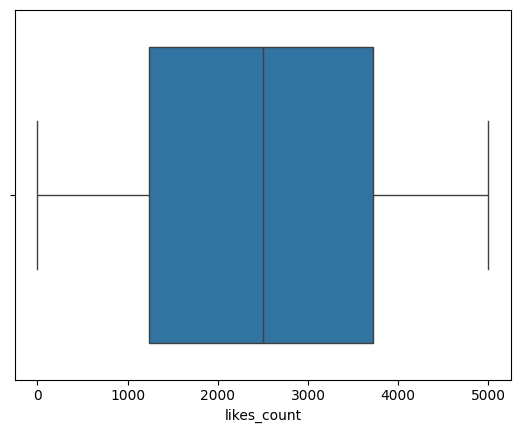

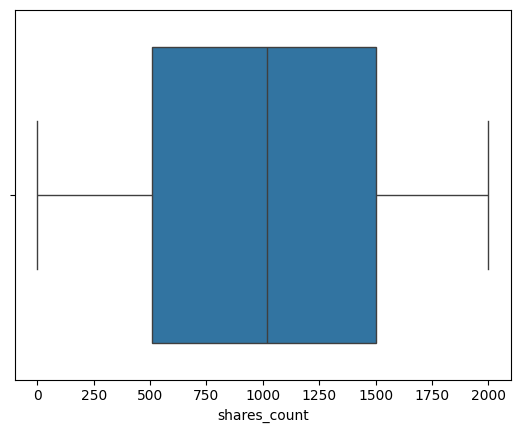

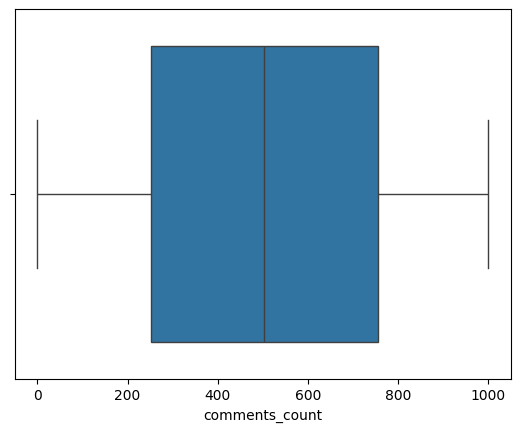

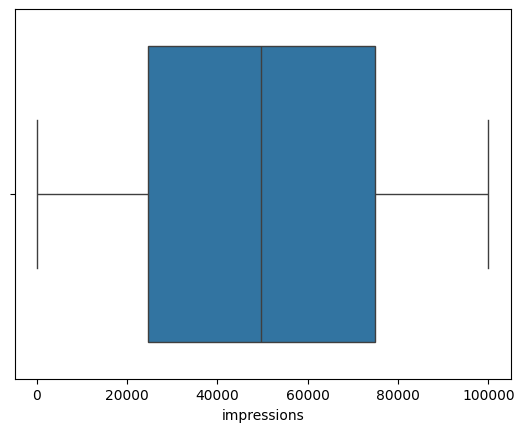

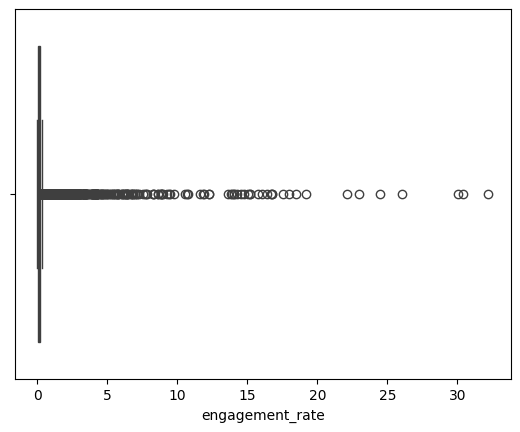

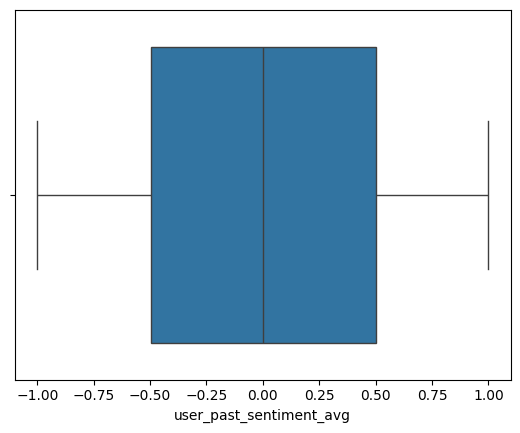

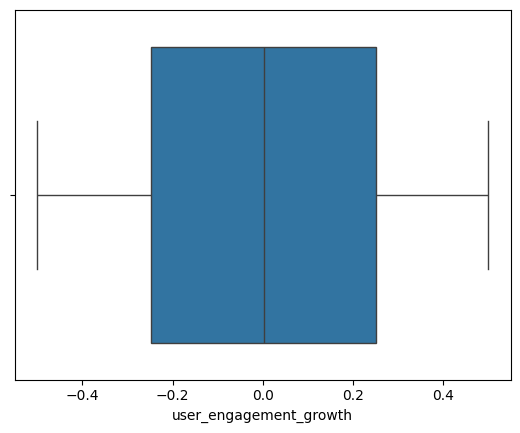

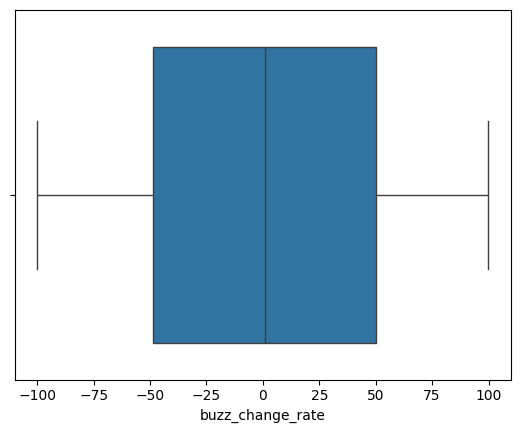

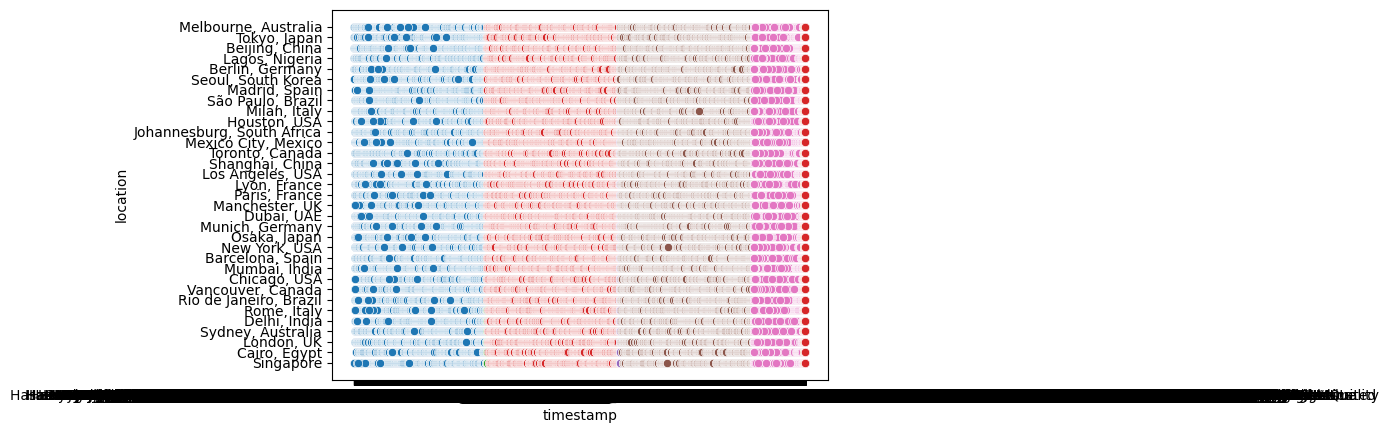

In [14]:
#EXPLORATORY DATA ANALYSIST
#-----------------------DESCRIBE-------------------------#
df.describe(include=object).T

#----------------------UNDERSTAND THE DISTRIBUTION--------------#
for i in df.select_dtypes(include='number').columns:
    sns.histplot(data=df,x=i)
    plt.show()

#-----------------------BOXPLOT TO IDENTIFY THE OUTLIERS-------------------#
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()


#-----------------------SCATTER PLOT TO UNDERSTAND THE RELATIONSHIP-----------#
df.select_dtypes(include=object).columns
for i in ['timestamp', 'day_of_week', 'platform', 'user_id', 'language', 'text_content', 'hashtags', 'topic_category', 'sentiment_label', 'emotion_type',
       'brand_name', 'product_name', 'campaign_name', 'campaign_phase']:
    sns.scatterplot(data=df,x=i,y='location')
plt.show()





,post_id,timestamp,user_id,location,language,text_content,hashtags,mentions,keywords,topic_category,...,platform_Twitter,platform_YouTube,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,campaign_phase_Post-Launch,campaign_phase_Pre-Launch
0,kcqbs6hxybia,09/12/2024 11:26,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NA,"price, unique, traditional, efficient",Pricing,...,False,False,True,False,False,False,False,False,False,False
1,vkmervg4ioos,28/07/2024 19:59,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO","delivery, slow",Delivery,...,True,False,False,False,True,False,False,False,True,False
2,memhx4o1x6yu,23/11/2024 14:00,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NA,"reliable, budget, durable, experience",Product,...,False,False,False,True,False,False,False,False,True,False
3,bhyo6piijqt9,16/09/2024 04:35,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport","improved, competitive, luxury, fast",Delivery,...,False,True,True,False,False,False,False,False,False,False
4,c9dkiomowakt,05/09/2024 21:03,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName","innovation, budget, helpful, luxury",Product,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,vpqni584supc,10/01/2025 07:55,user_ysobum87,"Seoul, South Korea",ar,Comparing Toyota Camry to the competition. Bes...,"#Food, #BestValue","@IndustryExpert, @InfluencerName","efficient, service",Support,...,False,False,False,False,False,False,False,False,False,True
11996,h8rvov0xym5z,04/12/2024 18:50,user_2jzngfsp,"New York, USA",pt,My two days review of Apple AirPods Pro: Highl...,#TrendAlert,"@TrendSetter, @NewsOutlet","responsive, user-friendly, service",Product,...,False,False,False,False,False,False,False,True,False,False
11997,14zrjm51ea3y,24/10/2024 19:11,user_0sidyfyh,"Lyon, France",ja,Just unboxed my new Dri-FIT from Nike. Best pu...,#Food,"@RetailSupport, @TechHelp","excellent, upgraded, luxury",Returns,...,False,False,False,False,False,True,False,False,True,False
11998,7bdmnv3rdj8n,12/11/2024 03:07,user_njyhr041,"Manchester, UK",fr,Comparing Toyota Camry to the competition. Doe...,"#SpecialOffer, #Promo, #Fashion","@BrandSupport, @TechHelp","price, stylish, sustainable",Pricing,...,False,False,False,False,False,False,True,False,True,False


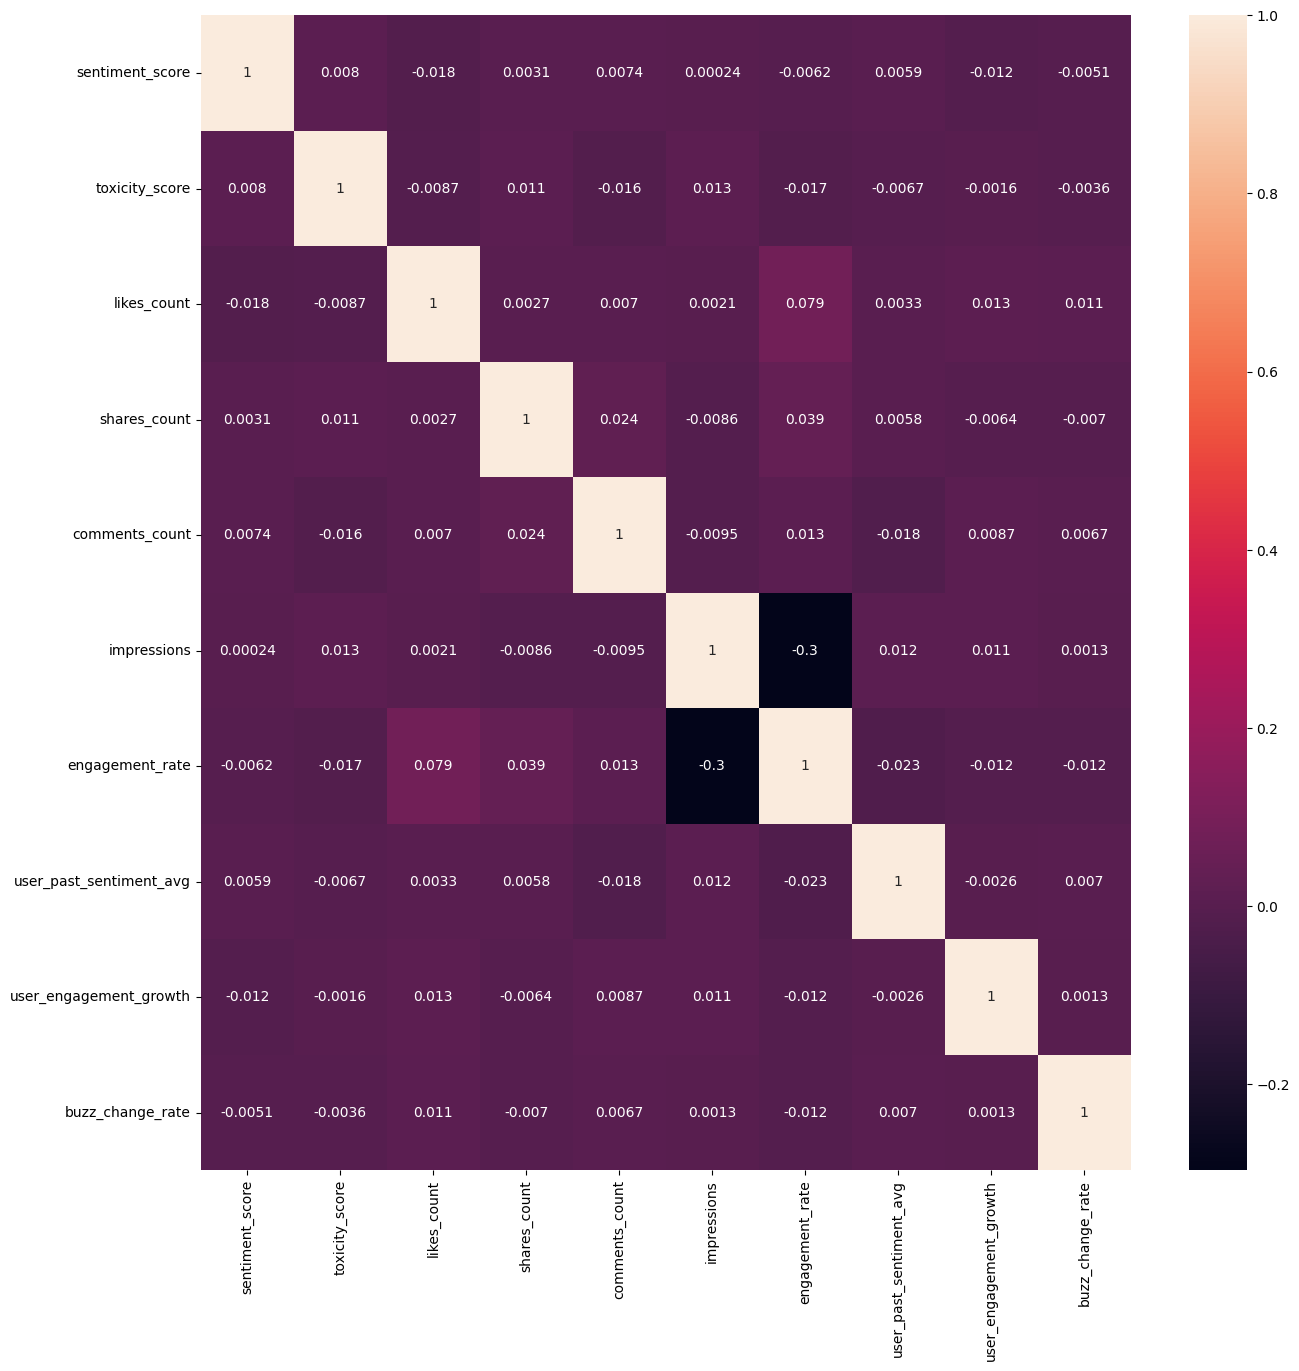

In [18]:
#---------------------CORRELATION WITH HEATMAP-----------------------------#
s=df.select_dtypes(include='number').corr()

plt.figure(figsize=(15,15))
sns.heatmap(s,annot=True)

#---------------------ENCODING DATA---------------------------------------#

dummy = pd.get_dummies(data=df,columns=["platform","day_of_week","campaign_phase"],drop_first=True)

dummy 